In [5]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
from torch.optim import Adam
from torchsummary import summary
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [6]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [15]:
data_df = pd.read_csv("./data/riceClassification.csv")
data_df.head()

,id,Area,MajorAxisLength,MinorAxisLength,Eccentricity,ConvexArea,EquivDiameter,Extent,Perimeter,Roundness,AspectRation,Class
0,1,4537,92.229316,64.012769,0.719916,4677,76.004525,0.657536,273.085,0.764510,1.440796,1
1,2,2872,74.691881,51.400454,0.725553,3015,60.471018,0.713009,208.317,0.831658,1.453137,1
2,3,3048,76.293164,52.043491,0.731211,3132,62.296341,0.759153,210.012,0.868434,1.465950,1
3,4,3073,77.033628,51.928487,0.738639,3157,62.551300,0.783529,210.657,0.870203,1.483456,1
4,5,3693,85.124785,56.374021,0.749282,3802,68.571668,0.769375,230.332,0.874743,1.510000,1


In [17]:
data_df.dropna(inplace=True)
data_df.drop(["id"],axis=1,inplace=True)

In [18]:
data_df.head()

,Area,MajorAxisLength,MinorAxisLength,Eccentricity,ConvexArea,EquivDiameter,Extent,Perimeter,Roundness,AspectRation,Class
0,4537,92.229316,64.012769,0.719916,4677,76.004525,0.657536,273.085,0.764510,1.440796,1
1,2872,74.691881,51.400454,0.725553,3015,60.471018,0.713009,208.317,0.831658,1.453137,1
2,3048,76.293164,52.043491,0.731211,3132,62.296341,0.759153,210.012,0.868434,1.465950,1
3,3073,77.033628,51.928487,0.738639,3157,62.551300,0.783529,210.657,0.870203,1.483456,1
4,3693,85.124785,56.374021,0.749282,3802,68.571668,0.769375,230.332,0.874743,1.510000,1


In [19]:
data_df.shape

(18185, 11)

In [23]:
print(f"Number of classes: {data_df['Class'].nunique()}")

Number of classes: 2


In [24]:
original_data_df = data_df.copy()

In [26]:
for column in data_df.columns:
    data_df[column] = data_df[column]/data_df[column].abs().max()

In [27]:
data_df.head()

,Area,MajorAxisLength,MinorAxisLength,Eccentricity,ConvexArea,EquivDiameter,Extent,Perimeter,Roundness,AspectRation,Class
0,0.444368,0.503404,0.775435,0.744658,0.424873,0.666610,0.741661,0.537029,0.844997,0.368316,1.0
1,0.281293,0.407681,0.622653,0.750489,0.273892,0.530370,0.804230,0.409661,0.919215,0.371471,1.0
2,0.298531,0.416421,0.630442,0.756341,0.284520,0.546380,0.856278,0.412994,0.959862,0.374747,1.0
3,0.300979,0.420463,0.629049,0.764024,0.286791,0.548616,0.883772,0.414262,0.961818,0.379222,1.0
4,0.361704,0.464626,0.682901,0.775033,0.345385,0.601418,0.867808,0.452954,0.966836,0.386007,1.0


In [28]:
X = np.array(data_df.iloc[:, :-1])
Y = np.array(data_df.iloc[:, -1])

In [29]:
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.3, random_state=42) 

In [30]:
X_test, X_val, y_test, y_val = train_test_split(X_test, y_test, test_size=0.5, random_state=42)

In [32]:
print(X_train.shape)
print(X_val.shape)
print(X_test.shape)


(12729, 10)
(2728, 10)
(2728, 10)


In [33]:
class dataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32).to(device)
        self.y = torch.tensor(y, dtype=torch.float32).to(device)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

In [34]:
training_data = dataset(X_train, y_train)
validation_data = dataset(X_val, y_val)
testing_data = dataset(X_test, y_test)

In [35]:
train_dataloader = DataLoader(training_data, batch_size=8, shuffle=True)
validation_dataloader = DataLoader(validation_data, batch_size=8, shuffle=True)
testing_dataloader = DataLoader(testing_data, batch_size=8, shuffle=True)

In [37]:
HIDDEN_NEURONS = 10
class MyModel(nn.Module):
    def __init__(self):
        super(MyModel, self).__init__()
        self.input_layer = nn.Linear(X.shape[1], HIDDEN_NEURONS)
        self.linear = nn.Linear(HIDDEN_NEURONS, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.input_layer(x)
        x = self.linear(x)
        x = self.sigmoid(x)
        return x

model = MyModel().to(device)

In [38]:
summary(model, input_size=(X.shape[1],))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Linear-1                   [-1, 10]             110
            Linear-2                    [-1, 1]              11
           Sigmoid-3                    [-1, 1]               0
Total params: 121
Trainable params: 121
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/backward pass size (MB): 0.00
Params size (MB): 0.00
Estimated Total Size (MB): 0.00
----------------------------------------------------------------


In [39]:
criterion = nn.BCELoss()
optimizer = Adam(model.parameters(), lr=0.001)


In [42]:
total_loss_train_plot = []
total_loss_validation_plot = []
total_acc_train_plot = []
total_acc_validation_plot = []


epochs = 10

for epoch in range(epochs):
    total_acc_train = 0
    total_loss_train = 0
    total_acc_validation = 0
    total_loss_validation = 0

    for data in train_dataloader:
        inputs, labels = data

        predictions = model(inputs).squeeze(1)

        batch_loss = criterion(predictions, labels)

        total_loss_train += batch_loss.item()

        acc = ((predictions).round()==labels).sum().item()

        total_acc_train += acc

        batch_loss.backward()
        optimizer.step()
        optimizer.zero_grad()

    with torch.no_grad():
        for data in validation_dataloader:
            inputs, labels = data

            predictions = model(inputs).squeeze(1)

            batch_loss = criterion(predictions, labels)

            total_loss_validation += batch_loss.item()

            acc = ((predictions).round()==labels).sum().item()

            total_acc_validation += acc
    total_loss_train_plot.append(round(total_loss_train/1000, 4))
    total_loss_validation_plot.append(round(total_loss_validation/1000, 4))

    total_acc_train_plot.append(round(total_acc_train/training_data.__len__(), 4))
    total_acc_validation_plot.append(round(total_acc_validation/validation_data.__len__(), 4))


    print(f"Epoch: {epoch+1}/{epochs}, Training Loss: {round(total_loss_train/1000, 4)}, Validation Loss: {round(total_loss_validation/1000, 4)}, Training Accuracy: {round(total_acc_train/training_data.__len__(), 4)}, Validation Accuracy: {round(total_acc_validation/validation_data.__len__(), 4)}")
    print("="*25)

Epoch: 1/10, Training Loss: 0.128, Validation Loss: 0.0194, Training Accuracy: 0.9845, Validation Accuracy: 0.9861
Epoch: 2/10, Training Loss: 0.0849, Validation Loss: 0.0168, Training Accuracy: 0.9855, Validation Accuracy: 0.9857
Epoch: 3/10, Training Loss: 0.0741, Validation Loss: 0.0171, Training Accuracy: 0.9853, Validation Accuracy: 0.9824
Epoch: 4/10, Training Loss: 0.0727, Validation Loss: 0.0151, Training Accuracy: 0.9855, Validation Accuracy: 0.9857
Epoch: 5/10, Training Loss: 0.0696, Validation Loss: 0.015, Training Accuracy: 0.9848, Validation Accuracy: 0.9861
Epoch: 6/10, Training Loss: 0.0686, Validation Loss: 0.0149, Training Accuracy: 0.986, Validation Accuracy: 0.9861
Epoch: 7/10, Training Loss: 0.0682, Validation Loss: 0.0151, Training Accuracy: 0.9852, Validation Accuracy: 0.9861
Epoch: 8/10, Training Loss: 0.0685, Validation Loss: 0.015, Training Accuracy: 0.9853, Validation Accuracy: 0.9857
Epoch: 9/10, Training Loss: 0.0686, Validation Loss: 0.0153, Training Accura

In [44]:
with torch.no_grad():
    total_acc_test = 0
    total_loss_test = 0

    for data in testing_dataloader:
        inputs, labels = data

        predictions = model(inputs).squeeze(1)

        batch_loss_test = criterion(predictions, labels)

        total_loss_test += batch_loss_test.item()

        acc = ((predictions).round()==labels).sum().item()

        total_acc_test += acc

    print(f"Testing Loss: {round(total_loss_test/1000, 4)}, Testing Accuracy: {round(total_acc_test/testing_data.__len__(), 4)}")

Testing Loss: 0.0098, Testing Accuracy: 0.989


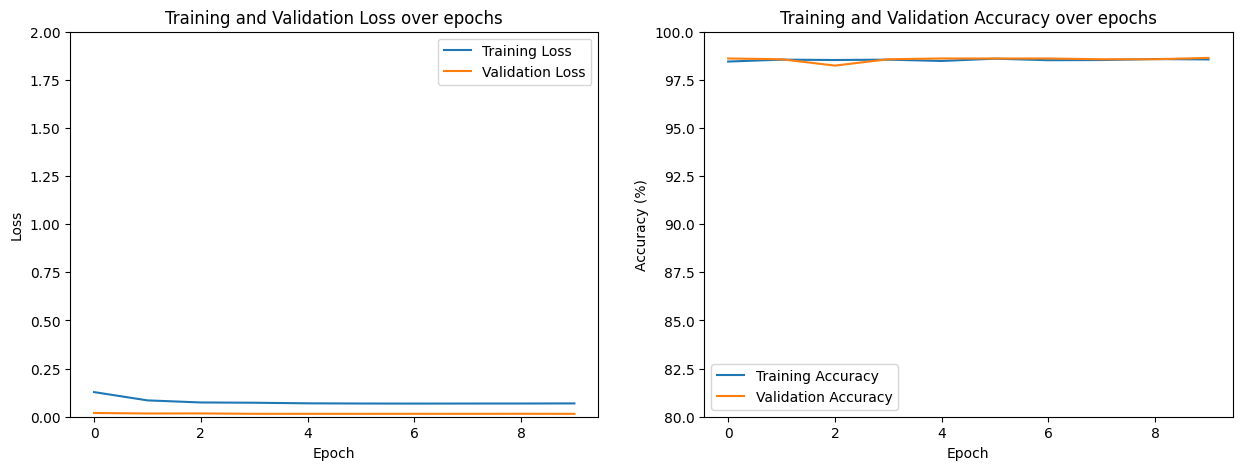

In [53]:
fig, ax = plt.subplots(1, 2, figsize=(15, 5))

ax[0].plot(total_loss_train_plot, label="Training Loss")
ax[0].plot(total_loss_validation_plot, label="Validation Loss")
ax[0].set_title("Training and Validation Loss over epochs")
ax[0].set_xlabel("Epoch")
ax[0].set_ylabel("Loss")
ax[0].set_ylim([0, 2])
ax[0].legend()

ax[1].plot([accuracy * 100 for accuracy in total_acc_train_plot], label="Training Accuracy")
ax[1].plot([accuracy * 100 for accuracy in total_acc_validation_plot], label="Validation Accuracy")
ax[1].set_title("Training and Validation Accuracy over epochs")
ax[1].set_xlabel("Epoch")
ax[1].set_ylabel("Accuracy (%)")
ax[1].set_ylim([80, 100])
ax[1].legend()

plt.show()

In [52]:
print(total_acc_train_plot
      )

[0.9845, 0.9855, 0.9853, 0.9855, 0.9848, 0.986, 0.9852, 0.9853, 0.9858, 0.9856]
